# show() and basic Rendering Control

This notebook demonstrates the `wb.show()` convenience method -- the primary one-liner for
getting data into the Workbench -- and the fundamental rendering control endpoints (position, screenshot).

You will learn how to:
- Show data with a single call: `wb.show(array, name=..., color=..., opacity=...)`
- Show a file from disk without loading it into Python
- Control parent nodes, visibility, and reinit behavior
- Use the fine-grained alternative (`storage.create()` + `node.set_data()` + `node.update_properties()`)
- Read and set the crosshair position
- Capture screenshots and display them inline

Hint: In the rest of the notebook explanation "mw" is referring to the mitk_workbench_remote package.

**Prerequisites:** A running MITK Workbench instance with the REST API enabled.

## 1. Connect to a running Workbench

In [1]:
import numpy as np
import mitk_workbench_remote as mw

instances = mw.discover(timeout=2)
if not instances:
    raise SystemExit("No running MITK Workbench found. Start one and try again.")

wb = instances[0]
print(f"Connected to: {wb.info.name} (MITK {wb.info.mitk_version}) at {wb.url}")

Connected to: MITK Workbench REST API (MITK 2026.06.00) at http://localhost:8080


## 2. show() basics

`wb.show()` is the primary one-liner for displaying data in the Workbench. It combines
node creation, data upload, property setting, and reinit into a single call.

It accepts `mw.Image` objects, `mw.MultiLabelSegmentation` objects, any types that can be converted into mw.Image (e.g. numpy arrays, SimpleITK images, MLArray objects)
or file paths. The return value is the newly created `DataNode`.

In [2]:
# Create a synthetic 3D gradient volume
size = 64
arr = np.sum(np.indices((size, size, size), dtype=np.float32), axis=0)
arr /= arr.max()

# Show it in the Workbench with a custom name, color, and opacity
node_gradient = wb.show(arr, name="Gradient", color=(0.2, 0.6, 1.0), opacity=0.8)
print(f"Created node: {node_gradient}")

Created node: <DataNode 'Gradient' (Image) @ /Gradient uid=node_15>


You can also pass an `mw.Image` with full spatial metadata (spacing, origin, direction):

In [3]:
# Create a sphere phantom with custom spacing
sphere = np.zeros((64, 64, 64), dtype=np.float32)
center = np.array([32, 32, 32])
for idx in np.ndindex(sphere.shape):
    dist = np.linalg.norm(np.array(idx) - center)
    sphere[idx] = max(0, 1.0 - dist / 20.0)

image = mw.Image(sphere, spacing=(0.5, 0.5, 0.5), origin=(16.0, 16.0, 16.0))
node_sphere = wb.show(image, name="Sphere", color=(1.0, 0.3, 0.0))
print(f"Created node: {node_sphere}")

Created node: <DataNode 'Sphere' (Image) @ /Sphere uid=node_16>


## 3. show() with a file path

When you pass a file path (string or `Path`), `show()` uploads the raw bytes directly
without deserializing the file into Python. The Workbench server parses the file format.
This is the most efficient way to load existing files. As long as the MITK Workbench knows this format it will be automatically handled.

The node name is inferred from the file stem (e.g. `"ct_scan.nrrd"` becomes `"ct_scan"`).

In [4]:
from pathlib import Path

# Save the sphere to a temporary NRRD file and re-show it from disk
tmp_file = Path("sphere_example.nrrd")
node_sphere.save_data(tmp_file)

node_from_file = wb.show(tmp_file, name="FromFile", color=(0.0, 1.0, 0.5))
print(f"Loaded from file: {node_from_file}")

# Clean up the temp file
tmp_file.unlink(missing_ok=True)

Loaded from file: <DataNode 'FromFile' (Image) @ /FromFile uid=node_17>


''

## 4. show() as a child node

Use the `parent` parameter to create the new node as a child of an existing node.
This is useful for organizing related data (e.g. a segmentation under its source image).

In [5]:
#remove the FromFile node to avoid cluttering the view
node_from_file.remove()

# Create a binary mask and show it as a child of the sphere node
mask = (sphere > 0.5).astype(np.uint8)
node_mask = wb.show(mask, name="ThresholdMask", parent=node_sphere, color=(1.0, 1.0, 0.0))
print(f"Child node: {node_mask}")
print(f"Parent path: {node_sphere.path}")
print(f"Child path:  {node_mask.path}")

Child node: <DataNode 'ThresholdMask' (Image) @ /Sphere/ThresholdMask uid=node_18>
Parent path: /Sphere
Child path:  /Sphere/ThresholdMask


## 5. hide_others

When `hide_others=True`, all existing nodes are hidden before the new data is shown.
This is handy when you want a clean view of just the new data.

In [6]:
# Show a new volume while hiding everything else
solo = np.random.default_rng(42).random((32, 32, 32), dtype=np.float32)
node_solo = wb.show(solo, name="SoloView", hide_others=True, color=(0.8, 0.2, 0.8))
print(f"Only '{node_solo.name}' is visible now.")

Only 'SoloView' is visible now.


## 6. ReinitMode

By default `show()` calls a global reinit (`ReinitMode.ALL_VISIBLE`) to fit all views to all visible data.
You can change this behavior:

- `ReinitMode.ALL_VISIBLE` (default) -- global reinit: fits views to all visible data
- `ReinitMode.NODE` -- fits views to just the newly shown node
- `ReinitMode.NONE` -- skips reinit entirely (useful e.g if you want to add something w/o altering the scene)

In [7]:
# Load a volume without reinit, then reinit once at the end
small_1 = np.random.default_rng(1).random((16, 16, 16), dtype=np.float32)

n1 = wb.show(small_1, name="Batch1", reinit=mw.ReinitMode.NONE)

# Now reinit to fit everything
print(f"Loaded {n1.name} w/o reinit.")

Loaded Batch1 w/o reinit.


In [8]:
# ReinitMode.NODE -- fit views to just the new node
big = np.zeros((128, 128, 128), dtype=np.float32)
big[40:90, 40:90, 40:90] = 1.0
node_big = wb.show(big, name="BigCube", reinit=mw.ReinitMode.NODE)
print(f"Views now fit to '{node_big.name}' only.")

Views now fit to 'BigCube' only.


## 7. Fine-grained alternative

`wb.show()` is a convenience wrapper. Under the hood it calls:

1. `wb.storage.create(name, parent=...)` -- create an empty node
2. `node.set_data(data)` -- upload data
3. `node.update_properties(visible=..., opacity=..., color=..., context=...)` -- set display properties (use `context=` for per-render-window properties)
4. `wb.reinit()` or `wb.reinit([node])` -- reinit the views

You can call these steps individually for more control.

In [9]:
# Equivalent of: wb.show(arr, name="Manual", color=(0.0, 1.0, 0.0), opacity=0.6)
manual_node = wb.storage.create("Manual")
manual_node.set_data(mw.Image(arr))
manual_node.update_properties(visible=True, opacity=0.6, color=(0.0, 1.0, 0.0))
wb.reinit([manual_node])
print(f"Created manually: {manual_node}")

Created manually: <DataNode 'Manual' (Image) @ /Manual uid=node_26>


## 8. Position control

The crosshair position can be read and set in world coordinates.
`get_position()` also returns the scene bounding box (the axis-aligned bounding box
of all loaded geometry), which is useful for navigating to specific locations.

In [10]:
# Read the current crosshair position and scene bounds
pos = wb.get_position()
print(f"Crosshair: {pos.position}")
print(f"Bounds min: {pos.bounds.min_position}")
print(f"Bounds max: {pos.bounds.max_position}")

Crosshair: (32.0, 31.0, 31.0)
Bounds min: (-0.5, -0.5, -0.5)
Bounds max: (63.5, 63.5, 63.5)


In [11]:
# Navigate to the center of the scene bounding box
if pos.bounds.min_position is not None and pos.bounds.max_position is not None:
    center = tuple(
        (lo + hi) / 2.0
        for lo, hi in zip(pos.bounds.min_position, pos.bounds.max_position)
    )
    wb.set_position(center)
    print(f"Moved crosshair to center: {center}")
else:
    print("No geometry loaded -- bounds are None.")

Moved crosshair to center: (31.5, 31.5, 31.5)


## 9. Screenshot

Capture a screenshot of the active Workbench window. The image is returned as raw bytes
(PNG or JPEG). You can optionally scale the output and save to a file.

In Jupyter, use `IPython.display.Image` to display the screenshot inline.

Screenshot: 316971 bytes


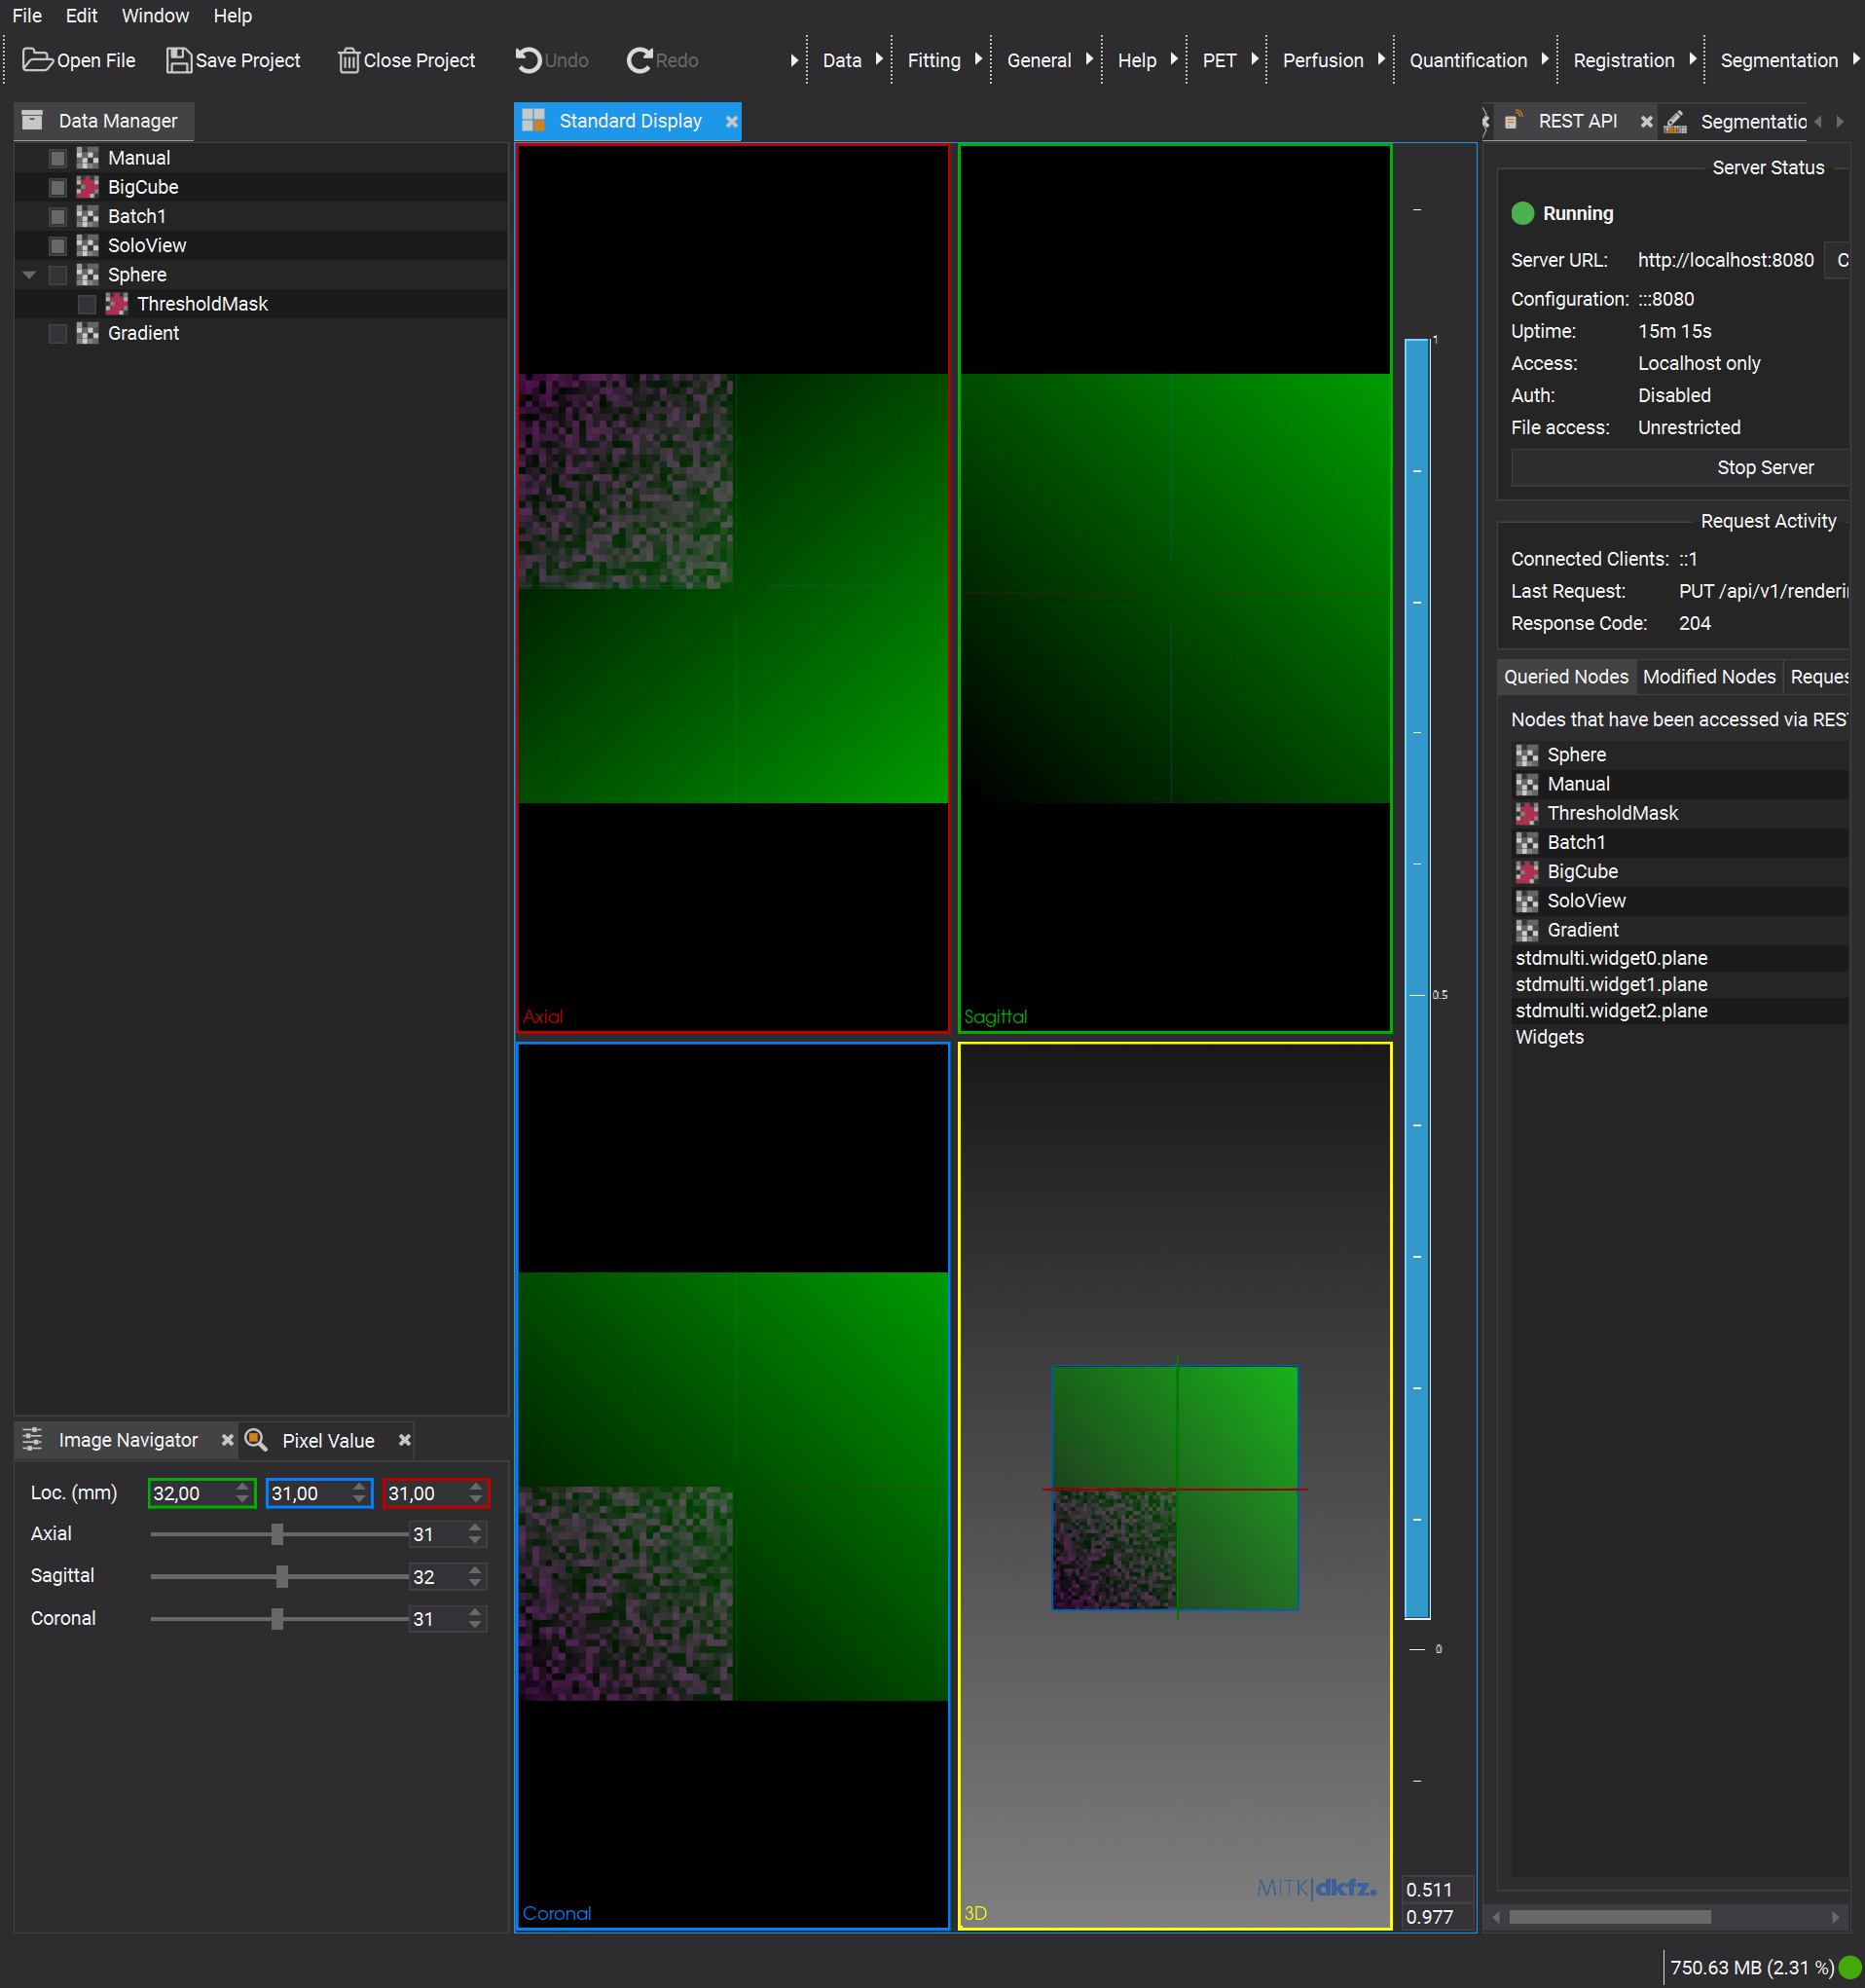

In [12]:
from IPython.display import Image as IPImage, display

# Capture at default resolution
png_bytes = wb.screenshot()
print(f"Screenshot: {len(png_bytes)} bytes")
display(IPImage(data=png_bytes))

Scaled screenshot: 116027 bytes


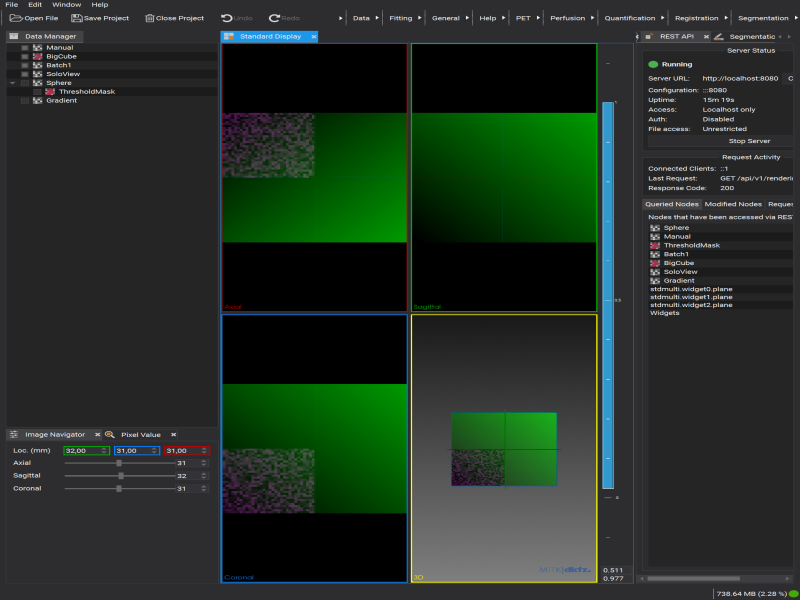

In [13]:
# Capture with specific dimensions
scaled = wb.screenshot(width=800, height=600)
print(f"Scaled screenshot: {len(scaled)} bytes")
display(IPImage(data=scaled))

In [14]:
# Save screenshot to file
wb.screenshot(path="workbench_capture.png")
print(f"Saved to workbench_capture.png ({Path('workbench_capture.png').stat().st_size} bytes)")

# Clean up
Path("workbench_capture.png").unlink(missing_ok=True)

Saved to workbench_capture.png (317011 bytes)


## 10. Clean up

Remove all nodes we created in this notebook.

In [15]:
for node in [node_gradient, node_sphere, node_solo,
             n1, node_mask, node_big, manual_node]:
    try:
        node.remove(recursive=True)
    except Exception:
        pass  # node may already be gone (e.g. child removed with parent)

print("Done.")

Done.
